# EDA — Financial Complaints Dataset
Consumer complaints dataset from Kaggle: 162k complaints across 5 product categories.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from pathlib import Path

In [25]:
df = pd.read_csv('/content/complaints_processed.csv', index_col=0)
print(df.shape)
df.head(3)

(162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping rec...
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comen...
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actua...


## 1. Basic info

In [26]:
print('Shape:', df.shape)
print('\nNull values:')
print(df.isnull().sum())
print('\nDtypes:')
print(df.dtypes)

Shape: (162421, 2)

Null values:
product       0
narrative    10
dtype: int64

Dtypes:
product      object
narrative    object
dtype: object


## 2. Class distribution

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

Class imbalance ratio (max/min): 6.7x


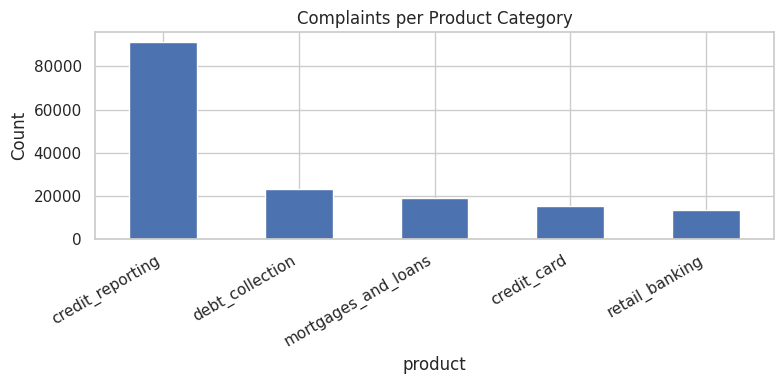

In [27]:
counts = df['product'].value_counts()
print(counts)
print(f'\nClass imbalance ratio (max/min): {counts.max() / counts.min():.1f}x')

counts.plot(kind='bar', figsize=(8, 4))
plt.title('Complaints per Product Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 3. Narrative text length

count    162411.0
mean         80.2
std         108.9
min           1.0
25%          27.0
50%          50.0
75%          95.0
max        2685.0
Name: word_count, dtype: float64


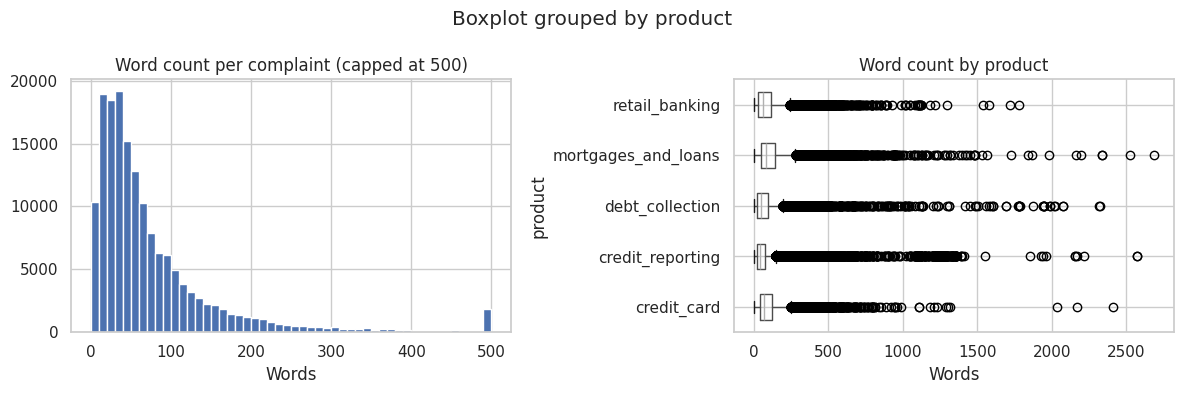

In [28]:
df['word_count'] = df['narrative'].str.split().str.len()
print(df['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['word_count'].clip(upper=500).hist(bins=50, ax=axes[0])
axes[0].set_title('Word count per complaint (capped at 500)')
axes[0].set_xlabel('Words')

df.boxplot(column='word_count', by='product', ax=axes[1], vert=False)
axes[1].set_title('Word count by product')
axes[1].set_xlabel('Words')
plt.tight_layout()
plt.show()


## 4. Top words per category

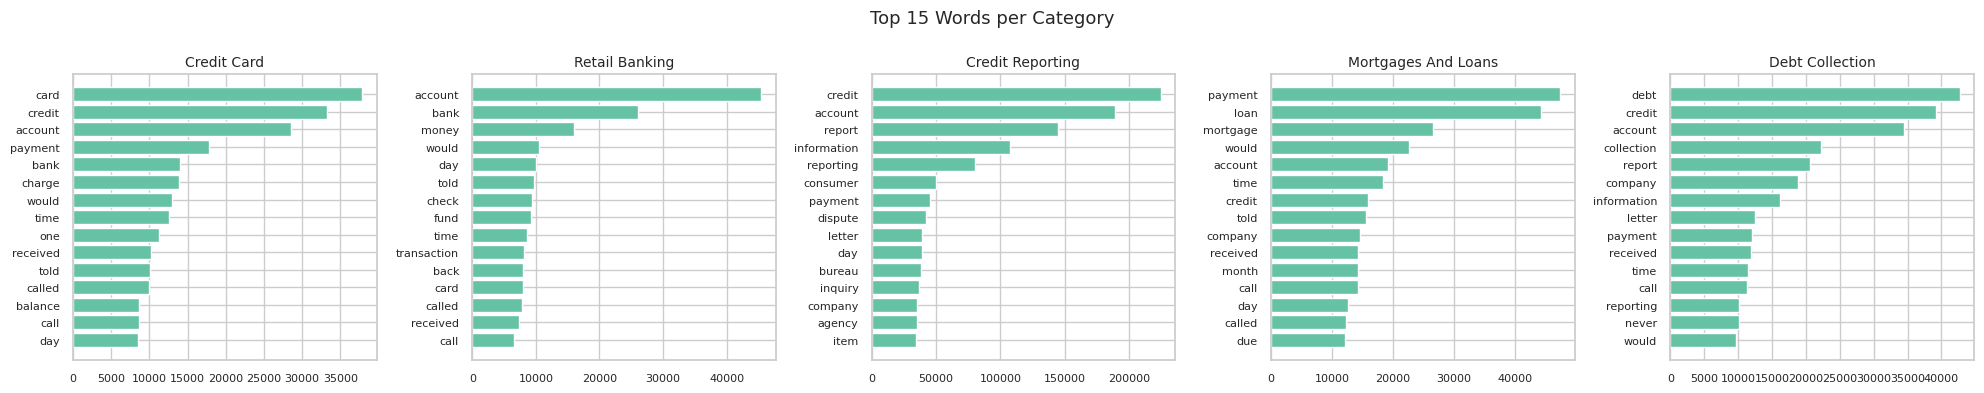

In [30]:
categories = df['product'].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(20, 4))

for ax, cat in zip(axes, categories):
    words = ' '.join(df[df['product'] == cat]['narrative'].dropna()).split()
    top = Counter(words).most_common(15)
    words_plot, freqs = zip(*top)
    ax.barh(words_plot[::-1], freqs[::-1], color=sns.color_palette('Set2', 1)[0])
    ax.set_title(cat.replace('_', ' ').title(), fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle('Top 15 Words per Category', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Word clouds per category

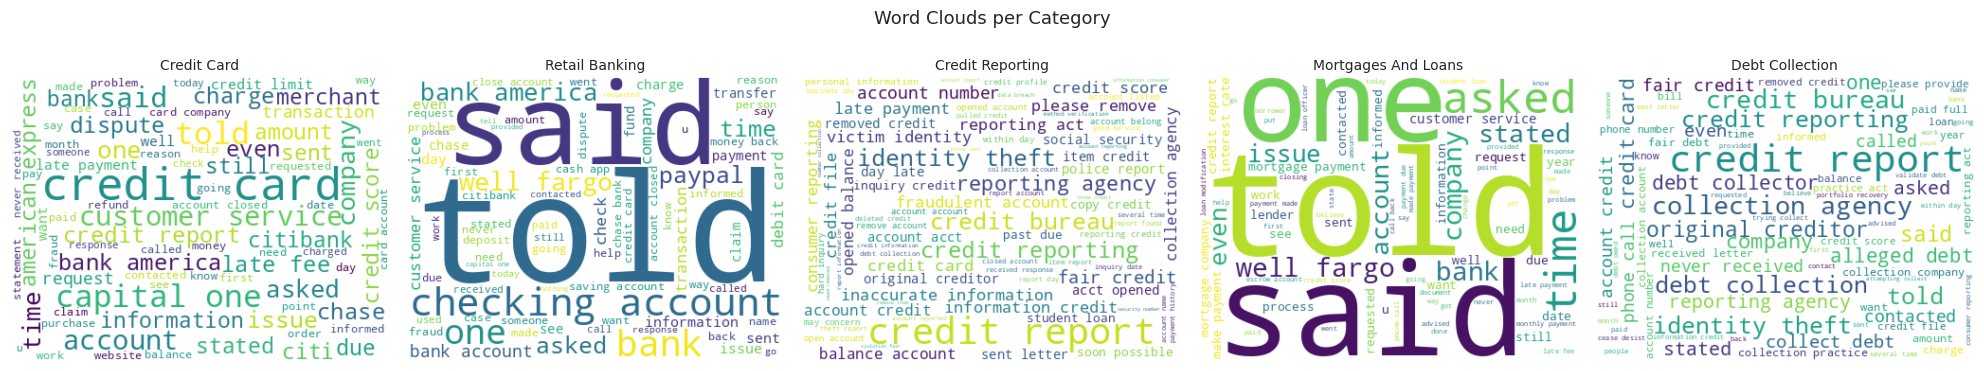

In [32]:
fig, axes = plt.subplots(1, len(categories), figsize=(20, 4))

for ax, cat in zip(axes, categories):
    text = ' '.join(df[df['product'] == cat]['narrative'].dropna())
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(cat.replace('_', ' ').title(), fontsize=10)

plt.suptitle('Word Clouds per Category', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Key takeaways

In [33]:
print('=== Key Takeaways ===')
print(f'Total complaints : {len(df):,}')
print(f'Categories       : {df["product"].nunique()}')
print(f'Class imbalance  : {counts.max() / counts.min():.1f}x (credit_reporting dominates)')
print(f'Median words     : {df["word_count"].median():.0f}')
print(f'Missing narratives: {df["narrative"].isnull().sum()}')

=== Key Takeaways ===
Total complaints : 162,421
Categories       : 5
Class imbalance  : 6.7x (credit_reporting dominates)
Median words     : 50
Missing narratives: 10
